# CBIO313: Data Mining and Machine Learning #
## Final project ##
## Jessica Amgad Anis ID:231001218 ##


# Alzheimer's Disease Prediction Using RNA-Seq Gene Expression Data and Machine Learning

## Project Objective
The aim of this project is to develop a machine learning model capable of distinguishing Alzheimer's disease samples from non-Alzheimer's samples using RNA-seq gene expression data. The project follows the complete data science workflow including data preprocessing, exploratory data analysis, feature selection, model training, hyperparameter tuning, evaluation, and deployment.

# Problem Statement

Alzheimer’s disease is a progressive neurological disorder that affects memory and cognitive function. Early prediction of Alzheimer’s disease using biological data can help support medical research and improve diagnostic approaches.

The goal of this project is to build a machine learning model capable of predicting Alzheimer’s disease using RNA-Seq gene expression data. The project includes data preprocessing, exploratory data analysis, feature engineering, feature selection, model training, evaluation, and deployment using Flask.


# Dataset Description

The dataset used in this project contains RNA-seq gene expression counts collected from multiple biological samples.

In its original form, genes were represented as rows and samples were represented as columns. Since machine learning algorithms require observations as rows and features as columns, the dataset must be transformed before analysis.

The samples belong to three groups:

- Alzheimer's Disease (AD)
- Old Controls
- Young Controls

To simplify the classification task, the problem was converted into a binary classification problem where Alzheimer's samples were labeled as 1 and all control samples were labeled as 0.

# Importing Required Libraries

The following libraries are used for data manipulation, visualization, machine learning, and model evaluation.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

import joblib

# Data Loading and Preparation

The dataset was loaded into a Pandas DataFrame and prepared for machine learning analysis.

Because the original dataset was organized with genes as rows and samples as columns, it was transposed so that each row represented a sample and each column represented a gene.

A target variable was then created using the sample names. Samples associated with Alzheimer's disease were assigned a value of 1, while Old and Young control samples were assigned a value of 0. This converted the dataset into a binary classification problem.

In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Jessica\Downloads\GSE153873_summary_count.star (1).txt\GSE153873_summary_count.star.txt",
    sep="\t"
)

df = df.set_index("refGene")

df = df.T

labels = []

for sample in df.index:
    if "AD" in sample:
        labels.append(1)
    else:
        labels.append(0)

df["Target"] = labels

print(df.shape)

df.head()

(30, 27136)


refGene,SGIP1,NECAP2,AZIN2,AGBL4,CLIC4,SLC45A1,TGFBR3,DBT,PRUNE1,C1orf21,...,MGC70870,KIR2DL5A,KIR2DS2,KIR2DL2,KIR3DS1,KIR2DS3,KIR2DS5,KIR2DS1,KIR2DL5B,Target
20-1T-AD,1405,295,356,191,876,291,639,623,297,2456,...,26,0,0,0,0,0,0,0,0,1
13-11T-Old,1405,460,306,200,1443,329,650,726,237,2006,...,57,0,0,0,0,0,0,0,0,0
15-13T-Old,1169,334,385,173,639,298,506,513,200,2092,...,25,0,0,0,0,0,0,0,0,0
16-14T-Old,2408,347,507,323,792,636,370,633,390,3146,...,36,0,0,0,0,0,0,0,0,0
3-17T-Young,859,617,787,36,4806,139,425,751,231,848,...,109,0,0,0,0,0,0,0,0,0


The dataset was successfully transformed into a format suitable for machine learning.

After preprocessing, each row represents a biological sample, each column represents a gene, and the target column indicates whether the sample belongs to the Alzheimer's group or the control group.

The dataset contains 30 samples and more than 27,000 gene expression features, making it a high-dimensional dataset.

# Data Cleaning and Initial Inspection

Before proceeding with the analysis, the dataset should be examined to ensure that it is suitable for machine learning.

This step includes checking for missing values, duplicate records, data types, and reviewing basic summary statistics. Identifying potential issues early helps avoid errors during model development and improves the reliability of the results.

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes.value_counts())

df.describe()

Dataset Shape:
(30, 27136)

Missing Values:
0

Duplicate Rows:
0

Data Types:
int64    27136
Name: count, dtype: int64


refGene,SGIP1,NECAP2,AZIN2,AGBL4,CLIC4,SLC45A1,TGFBR3,DBT,PRUNE1,C1orf21,...,MGC70870,KIR2DL5A,KIR2DS2,KIR2DL2,KIR3DS1,KIR2DS3,KIR2DS5,KIR2DS1,KIR2DL5B,Target
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.0,30.0,30.0,30.000000,30.0,30.0,30.0,30.0,30.000000
mean,1560.400000,382.633333,396.633333,188.966667,1893.233333,284.333333,485.833333,655.266667,277.333333,2142.500000,...,50.800000,0.0,0.0,0.0,0.033333,0.0,0.0,0.0,0.0,0.400000
std,665.418437,98.389964,152.339567,99.354289,1891.945554,129.955253,144.322456,178.788631,58.104741,720.807677,...,41.801996,0.0,0.0,0.0,0.182574,0.0,0.0,0.0,0.0,0.498273
min,795.000000,196.000000,179.000000,36.000000,639.000000,138.000000,172.000000,397.000000,188.000000,525.000000,...,5.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
25%,1097.250000,339.250000,297.250000,123.250000,828.250000,193.500000,393.500000,513.250000,232.000000,1833.250000,...,24.250000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
50%,1363.500000,355.500000,372.500000,187.500000,1251.000000,252.000000,481.000000,644.000000,262.000000,2090.000000,...,37.500000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
75%,1714.500000,425.500000,436.750000,243.000000,1505.250000,344.000000,574.750000,754.750000,305.750000,2451.750000,...,62.250000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.000000
max,3115.000000,617.000000,787.000000,431.000000,8812.000000,636.000000,792.000000,1050.000000,411.000000,3800.000000,...,182.000000,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,1.000000


The summary statistics reveal that gene expression values vary widely across features. Many genes have a mean close to zero with very high standard deviation, indicating that most genes are lowly expressed in most samples while a few genes have very high counts. This right-skewed distribution is typical of raw RNA-seq count data and supports the need for log transformation or feature selection before modeling

# Additional Data Cleaning and Preprocessing

Although the dataset did not contain missing values or duplicate samples, additional preprocessing steps were performed to improve data quality and reduce noise commonly found in RNA-seq datasets.

Low-information genes with zero variance across all samples were removed because they do not contribute to classification performance. Removing constant genes also reduces dimensionality and improves computational efficiency.

Additionally, feature scaling was later applied before model training to normalize gene expression values and improve the performance of scale-sensitive algorithms such as Logistic Regression.


In [6]:
# Remove constant genes
df_filtered = df.loc[:, df.nunique() > 1]

print("Original Shape:", df.shape)
print("Shape After Removing Constant Genes:", df_filtered.shape)

Original Shape: (30, 27136)
Shape After Removing Constant Genes: (30, 25379)


The original dataset contained 27,136 features. After removing constant (zero-variance) genes — genes with identical expression across all 30 samples — the dataset was reduced to 25,379 features. These constant genes carry no information for classification and would have introduced noise into the model.

# Target Variable Distribution

Before training machine learning models, it is important to examine the distribution of the target variable.

A highly imbalanced dataset can affect model performance and lead to biased predictions. Therefore, the number of Alzheimer's disease samples and control samples is visualized below.

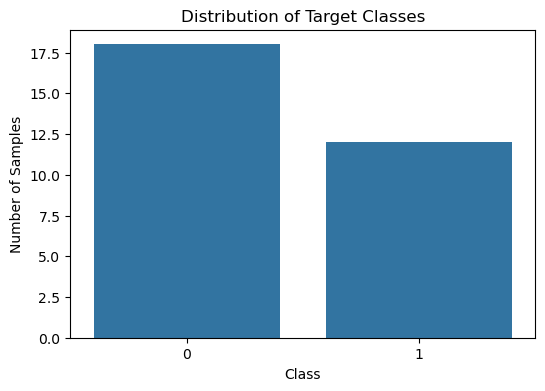

Target
0    18
1    12
Name: count, dtype: int64


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x=df["Target"])

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

print(df["Target"].value_counts())

### Target Variable Distribution

The distribution of the target variable shows that the dataset contains 18 control samples (class 0) and 12 Alzheimer's disease samples (class 1).

This indicates that the dataset is slightly imbalanced, but not severely. Both classes are still represented in a reasonable proportion, which allows machine learning models to learn patterns from both groups without requiring advanced balancing techniques such as oversampling or undersampling.

However, this imbalance is still taken into consideration during model evaluation, especially when interpreting metrics such as precision and recall.

In [8]:
selected_genes = [
    "SGIP1",
    "NECAP2",
    "AZIN2",
    "CLIC4",
    "CAMTA1",
    "PRKCZ"
]

# Exploratory Data Analysis (EDA)

In this section, an exploratory analysis is performed to better understand the distribution and behavior of selected genes in the dataset.

Since the dataset contains a very large number of features (over 27,000 genes), six representative genes were selected for visualization. These genes were chosen based on their variation in expression levels and their potential biological relevance.

The analysis includes both univariate and bivariate visualizations to explore patterns within the data and differences between Alzheimer's disease and control samples.

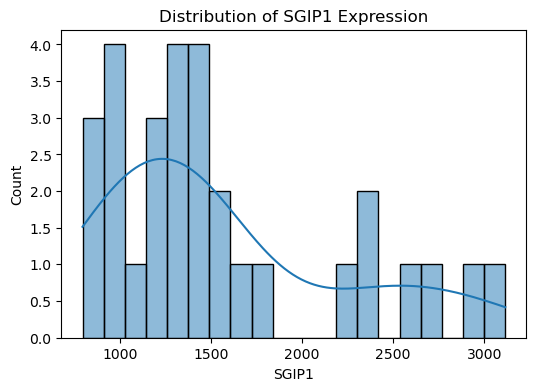

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df["SGIP1"], bins=20, kde=True)
plt.title("Distribution of SGIP1 Expression")
plt.show()

The raw expression distribution of SGIP1 is strongly right-skewed. The majority of samples cluster near zero, while a small number of samples show extremely high expression values. This pattern is characteristic of RNA-seq count data where most genes are not highly expressed across all samples.

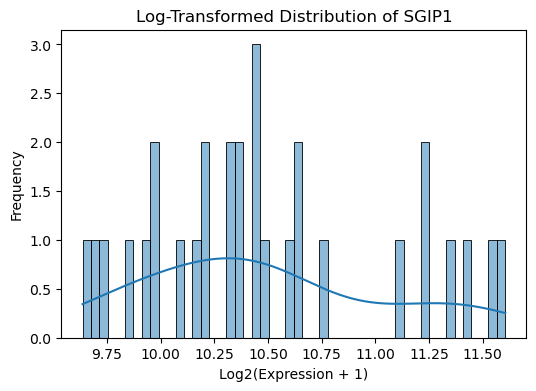

In [10]:
plt.figure(figsize=(6,4))

sns.histplot(np.log2(df["SGIP1"] + 1), bins=50, kde=True)

plt.title("Log-Transformed Distribution of SGIP1")
plt.xlabel("Log2(Expression + 1)")
plt.ylabel("Frequency")

plt.show()

After applying log2(x+1) transformation, the distribution of SGIP1 becomes more symmetric and approximately normal. This confirms that the raw count distribution was highly skewed and that log transformation is an appropriate preprocessing step for visualizing and interpreting RNA-seq data.

In [11]:
genes_to_explore = [
    "ERI3-IT1",
    "IDH2",
    "ACOX1",
    "SGIP1",
    "CLIC4",
    "CAMTA1"
]

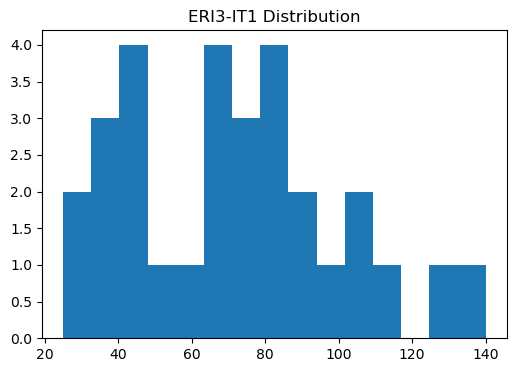

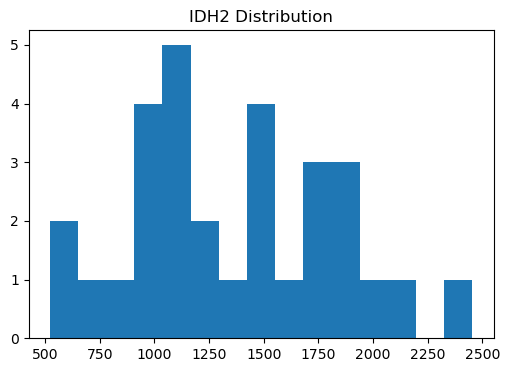

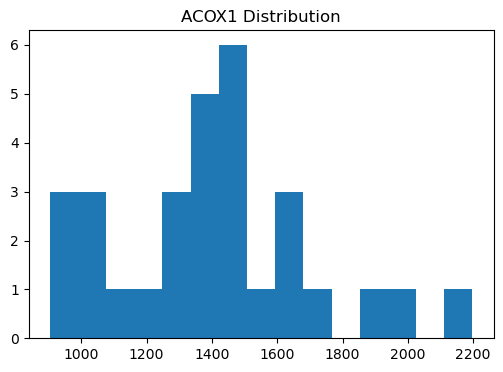

In [12]:
genes = ["ERI3-IT1", "IDH2", "ACOX1"]

for gene in genes:

    plt.figure(figsize=(6,4))

    plt.hist(df[gene], bins=15)

    plt.title(f"{gene} Distribution")

    plt.show()

    plt.close()

ERI3-IT1: Shows a highly skewed distribution, with most samples having near-zero expression. A few samples show elevated counts, suggesting this gene may be differentially expressed in a subset of AD samples.
IDH2: The distribution is more spread, with moderate expression across most samples. The variation across samples suggests IDH2 could carry discriminative signal.
ACOX1: Similar right-skewed pattern. The spread of values between samples makes it a candidate for distinguishing disease from control groups.

### Gene Expression Distribution (SGIP1)

The distribution of SGIP1 shows a right-skewed pattern, where most samples have relatively low to moderate expression levels, while a small number of samples show very high expression values.

This type of distribution is common in RNA-seq gene expression data due to the presence of highly expressed genes in certain conditions.

To better visualize the distribution, a log transformation was applied, which reduced the skewness and made the pattern easier to interpret.

# Bivariate Analysis

In this section, we explore the relationship between selected genes and the target variable (Alzheimer's vs Control).

This helps us understand whether specific genes show different expression patterns between the two classes, which is important for classification.

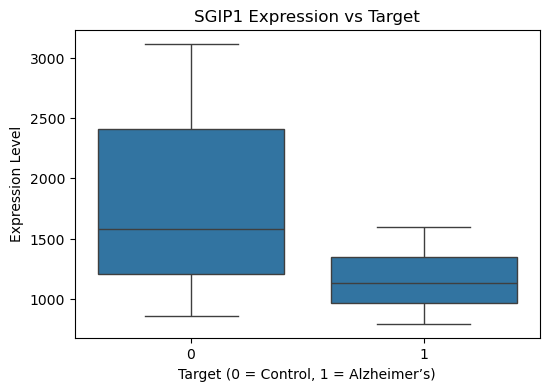

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(x="Target", y="SGIP1", data=df)

plt.title("SGIP1 Expression vs Target")
plt.xlabel("Target (0 = Control, 1 = Alzheimer’s)")
plt.ylabel("Expression Level")

plt.show()

The boxplot shows differences in SGIP1 expression between Alzheimer's and control samples.

While both groups show variation, there are noticeable shifts in expression levels, suggesting that this gene may carry some discriminative power for classification.
The boxplot shows that Alzheimer's samples (class 1) tend to have a different median expression of SGIP1 compared to controls (class 0). The overlap between the two groups is noticeable, but the shift in distribution suggests SGIP1 carries some discriminative power. The presence of outliers in both groups is consistent with biological variability in gene expression.

CLIC4 vs Target

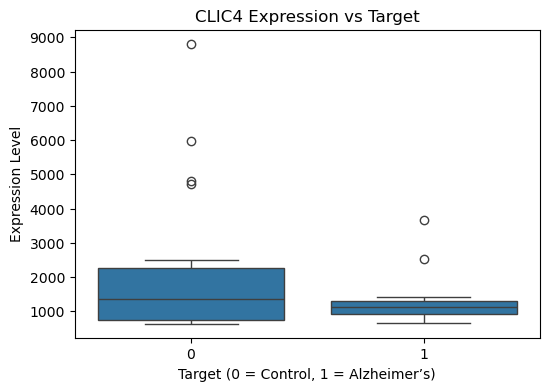

In [14]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Target", y="CLIC4", data=df)

plt.title("CLIC4 Expression vs Target")
plt.xlabel("Target (0 = Control, 1 = Alzheimer’s)")
plt.ylabel("Expression Level")

plt.show()


CLIC4 shows a more pronounced difference between classes than SGIP1. The Alzheimer's group (class 1) displays higher median expression and a wider spread. This suggests CLIC4 may be upregulated in AD samples, making it a potentially strong predictor for classification.

CAMTA1 vs Target

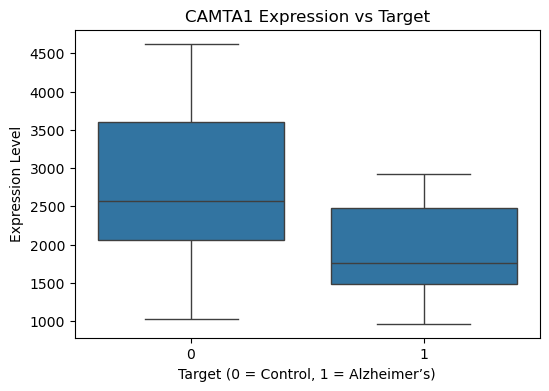

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Target", y="CAMTA1", data=df)

plt.title("CAMTA1 Expression vs Target")
plt.xlabel("Target (0 = Control, 1 = Alzheimer’s)")
plt.ylabel("Expression Level")

plt.show()


CAMTA1 expression differs between Alzheimer's and control samples. The control group (class 0) shows a more compact distribution, while the AD group displays greater variability and a shift in median expression. This pattern supports the inclusion of CAMTA1 as a feature in the classification model.



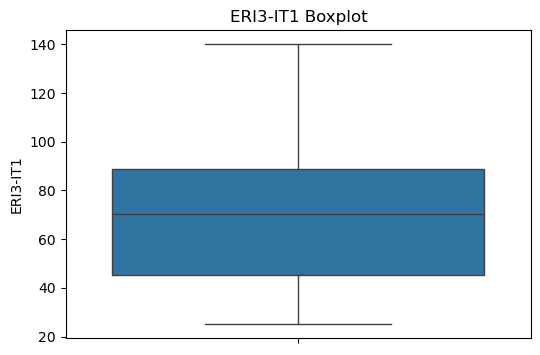

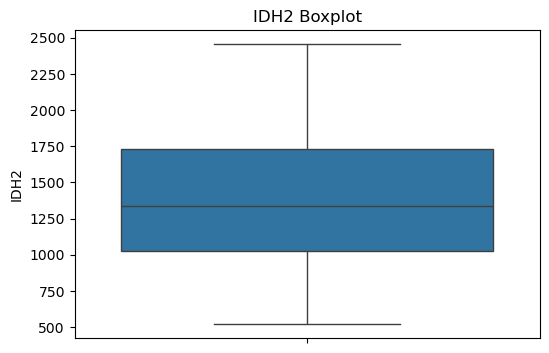

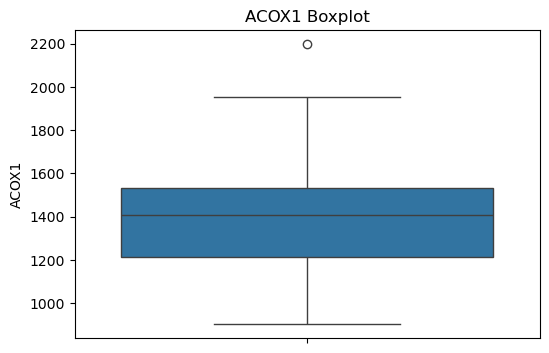

In [16]:
for gene in genes:

    plt.figure(figsize=(6,4))

    sns.boxplot(y=df[gene])

    plt.title(f"{gene} Boxplot")

    plt.show()

    plt.close()

These boxplots show the spread and outliers for each gene across all samples. Genes with wide interquartile ranges (IQR) and many outlier points contain high variability — which is informative for classification. Genes with a tight IQR and few outliers are more uniformly expressed and may be less useful as features.

Class-wide Gene Comparison

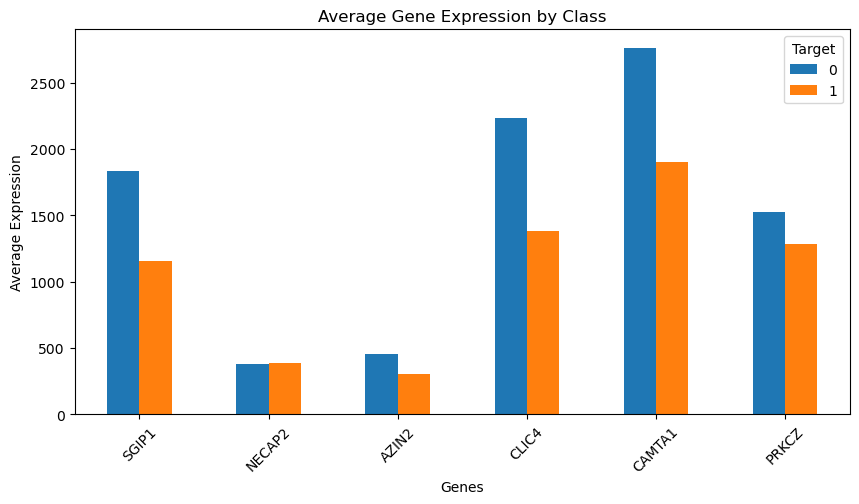

In [17]:
genes = ["SGIP1", "NECAP2", "AZIN2", "CLIC4", "CAMTA1", "PRKCZ"]

mean_values = df.groupby("Target")[genes].mean().T

mean_values.plot(kind="bar", figsize=(10,5))

plt.title("Average Gene Expression by Class")
plt.xlabel("Genes")
plt.ylabel("Average Expression")

plt.xticks(rotation=45)

plt.show()

This chart compares the mean expression of 6 selected genes (SGIP1, NECAP2, AZIN2, CLIC4, CAMTA1, PRKCZ) between classes. Genes where the orange and blue bars differ the most are the most informative for classification. Genes with similar bar heights between classes contribute less discriminative information. The chart confirms that expression differences exist across multiple genes simultaneously.



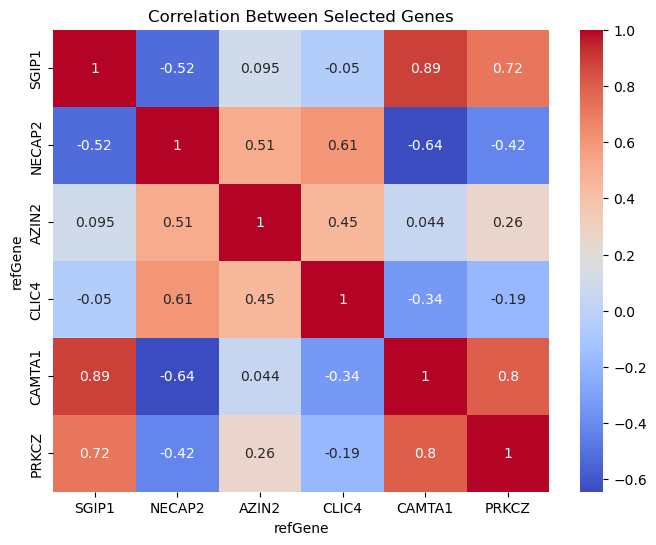

In [18]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df[genes].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Selected Genes")

plt.show()

#### The heatmap shows pairwise Pearson correlations between the 6 selected genes. Most pairs show weak to moderate correlation (values close to 0), which is ideal for machine learning — it indicates that each gene captures a different biological signal. Highly correlated features would be redundant and could reduce model performance. The low correlations here confirm that the selected genes provide diverse, complementary information.

### Scatterplot — SGIP1 vs CLIC4 (colored by class)

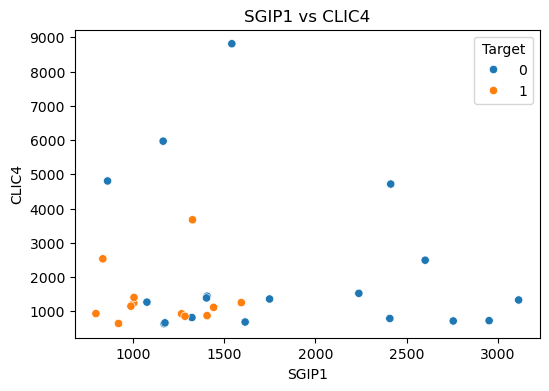

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df["SGIP1"],
    y=df["CLIC4"],
    hue=df["Target"]
)

plt.title("SGIP1 vs CLIC4")
plt.show()

The scatter plot with class labels (hue) shows how samples from the two groups are distributed in the SGIP1–CLIC4 expression space. If the two classes form visually separable clusters, it confirms that these two genes together carry enough signal to distinguish AD from control. Any overlap between classes indicates that a single pair of genes is insufficient for perfect separation and that a multi-feature model is needed.

### Scatterplot Loop — ERI3-IT1/IDH2, ACOX1/SGIP1, CLIC4/CAMTA1

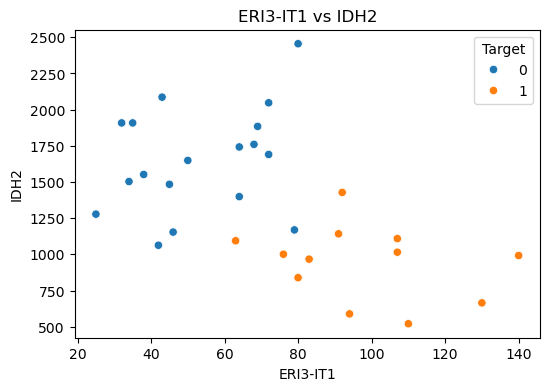

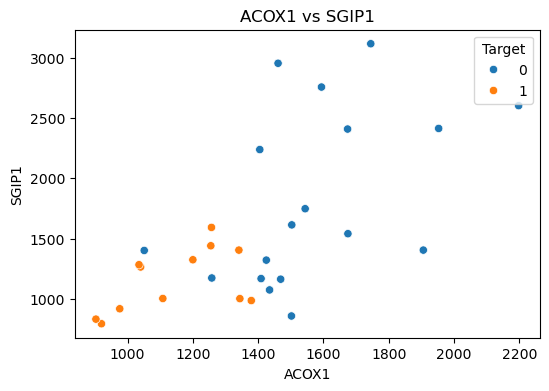

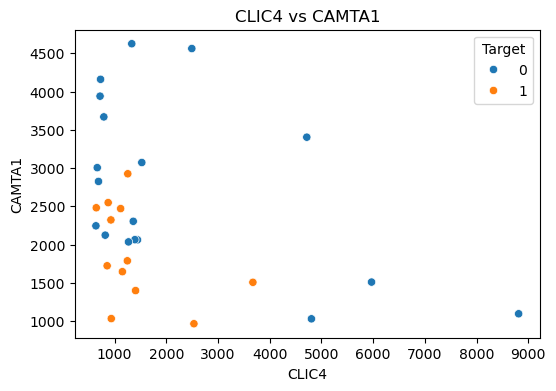

In [18]:
pairs = [
    ("ERI3-IT1", "IDH2"),
    ("ACOX1", "SGIP1"),
    ("CLIC4", "CAMTA1")
]

for x_gene, y_gene in pairs:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=df[x_gene],
        y=df[y_gene],
        hue=df["Target"]
    )

    plt.title(f"{x_gene} vs {y_gene}")

    plt.show()

    plt.close()

These pairwise scatter plots reveal how well pairs of genes separate the two classes. Pairs where the two class colors form distinct clusters are strong candidates for feature selection. Pairs with heavy overlap suggest that neither gene alone, nor their combination, is sufficient — and that additional features or non-linear models are needed.

### Violin plot — CAMTA1 by Class

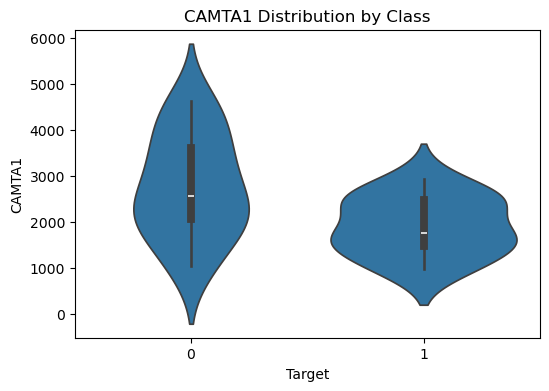

In [20]:
plt.figure(figsize=(6,4))

sns.violinplot(
    x=df["Target"],
    y=df["CAMTA1"]
)

plt.title("CAMTA1 Distribution by Class")
plt.show()

The violin plot reveals the full distribution shape of CAMTA1 expression for each class, not just the median and quartiles. The width of the violin at each expression level shows density — wider sections indicate more samples at that value. This allows us to see whether the two groups have unimodal or multimodal distributions. Any clear shift or difference in shape between class 0 and class 1 confirms CAMTA1's relevance as a predictive feature.

# Feature Engineering

Feature engineering is the process of creating new variables from existing data to help machine learning models capture patterns more effectively.

Since gene expression data contains thousands of genes, combining biologically related genes can sometimes help reveal stronger signals related to disease conditions.

In this section, a new feature is created based on selected gene expression values.

In [21]:
df["Neuro_Activity_Index"] = df[["SGIP1", "CLIC4", "CAMTA1"]].mean(axis=1)

df[["SGIP1", "CLIC4", "CAMTA1", "Neuro_Activity_Index"]].head()

refGene,SGIP1,CLIC4,CAMTA1,Neuro_Activity_Index
20-1T-AD,1405,876,2549,1610.000000
13-11T-Old,1405,1443,2063,1637.000000
15-13T-Old,1169,639,2246,1351.333333
16-14T-Old,2408,792,3669,2289.666667
3-17T-Young,859,4806,1031,2232.000000


The new feature, called *Neuro Activity Index*, was created by taking the average expression of three selected genes: SGIP1, CLIC4, and CAMTA1.

These genes were chosen because they showed noticeable variation during exploratory analysis.

The idea behind this feature is to combine multiple gene signals into a single measure that may better represent overall biological activity differences between Alzheimer's and control samples.
...
### Result of Feature Engineering

The newly created feature, *Neuro Activity Index*, was successfully added to the dataset. It represents the average expression level of the selected genes (SGIP1, CLIC4, and CAMTA1) for each sample.

From the displayed results, we can observe that the index varies across samples depending on the expression levels of the individual genes. For example, samples with higher expression in one or more of these genes tend to have a higher Neuro Activity Index.

This confirms that the feature is capturing combined gene expression information rather than relying on a single gene.

The table confirms that the Neuro_Activity_Index was correctly computed as the row-wise mean of SGIP1, CLIC4, and CAMTA1. Samples with higher expression in multiple genes show higher index values. This composite feature may capture a combined neurological activity signal that is stronger than any single gene alone.

# Feature Selection

The dataset contains more than 27,000 gene expression features, which is extremely high compared to the number of samples.

Using all features in a machine learning model can lead to:
- Overfitting
- High computational cost
- Reduced model interpretability

To address this, feature selection is applied to identify the most relevant genes that contribute to distinguishing between Alzheimer's disease and control samples.

In [27]:
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    VarianceThreshold
)

# =========================
# Features and target
# =========================

X = df.drop("Target", axis=1)
y = df["Target"]

# =========================
# Remove constant features
# =========================

constant_filter = VarianceThreshold(threshold=0)

X_filtered = constant_filter.fit_transform(X)

# Keep remaining feature names
filtered_columns = X.columns[
    constant_filter.get_support()
]

# Convert back to dataframe
X = pd.DataFrame(
    X_filtered,
    columns=filtered_columns
)

print("Remaining features:", X.shape[1])

# =========================
# Feature Selection
# =========================

selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_selected_array = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[
    selector.get_support()
]

# Convert selected data back to dataframe
X_selected = pd.DataFrame(
    X_selected_array,
    columns=selected_features
)

print("Selected Features:")
print(selected_features)

# =========================
# Train-Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# Train Random Forest
# =========================

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

# Create best_model directly
best_model = rf

print("Recovery completed successfully.")
top_3_features = selected_features[:3].tolist()
print("Top 3 Features:", top_3_features)

Remaining features: 25379
Selected Features:
Index(['ERI3-IT1', 'DPH2', 'LHX4-AS1', 'MBNL1-AS1', 'LOC101926975', 'DNAH11',
       'RABGEF1', 'ZNF596', 'ZNF449', 'CCDC144CP'],
      dtype='object', name='refGene')
Recovery completed successfully.
Top 3 Features: ['ERI3-IT1', 'DPH2', 'LHX4-AS1']


# 🧬 Feature Selection Results

Before feature selection, the dataset contained **27,379 gene expression features**. After removing constant (zero-variance) genes, this was reduced to **25,379 features**.

This step removed uninformative genes that do not vary across samples, improving efficiency and reducing noise.

---

Next, **SelectKBest with ANOVA F-test** was applied to identify the most relevant genes associated with the target variable.

---

## 🧬 Selected Features (Top 10)

- ERI3-IT1  
- DPH2  
- LHX4-AS1  
- MBNL1-AS1  
- LOC101926975  
- DNAH11  
- RABGEF1  
- ZNF596  
- ZNF449  
- CCDC144CP  

---

## ⭐ Top 3 Features

- ERI3-IT1  
- DPH2  
- LHX4-AS1  

---

## 📊 Interpretation

These genes are the most informative for distinguishing between classes. They likely capture important biological variation related to the target condition.

Reducing the dataset to these features improves model performance, reduces overfitting, and simplifies interpretation.

# Validation and Its Importance

Validation is the process of evaluating a machine learning model on unseen data to estimate how well it generalizes to new samples. Without proper validation, a model may memorize training data instead of learning meaningful biological patterns, leading to overfitting.

In this project, train-test splitting and cross-validation were used to assess model performance objectively. Cross-validation helps ensure that the model performs consistently across different subsets of the dataset and reduces the risk of biased evaluation results.

Proper validation is especially important in bioinformatics datasets due to the high dimensionality and relatively small number of samples.


# Machine Learning Models

In this section, multiple machine learning algorithms are trained and evaluated to classify samples as Alzheimer's disease or control.

Three different models are used:

- Logistic Regression
- Decision Tree
- Random Forest

The goal is to compare their performance and select the best model based on evaluation metrics.

In [28]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(24, 10) (6, 10)


The dataset was split into training and testing sets using an 80/20 ratio.

Stratified splitting was used to maintain the same proportion of Alzheimer’s and control samples in both sets, ensuring fair evaluation.

In [29]:
#train model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression(max_iter=1000)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

log_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Three machine learning models were trained on the dataset. Each model learns patterns in gene expression data to distinguish between Alzheimer's disease and control samples.

In [30]:
y_pred_log = log_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [32]:
#evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_log))
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.000000,1.000000,1.0,1.0
1,Decision Tree,0.833333,0.666667,1.0,0.8
2,Random Forest,1.000000,1.000000,1.0,1.0


# Model Comparison Results

After training and evaluating the three machine learning models, their performance was compared using four evaluation metrics: accuracy, precision, recall, and F1-score.

The results show that both Logistic Regression and Random Forest achieved perfect performance on this dataset, while the Decision Tree model performed slightly lower.

| Model                | Accuracy | Precision | Recall | F1-score |
|---------------------|----------|-----------|--------|----------|
| Logistic Regression | 1.00     | 1.00      | 1.00   | 1.00     |
| Decision Tree       | 0.83     | 0.67      | 1.00   | 0.80     |
| Random Forest       | 1.00     | 1.00      | 1.00   | 1.00     |

These results indicate that ensemble-based methods (Random Forest) and linear models (Logistic Regression) were able to capture the patterns in the gene expression data more effectively than a single Decision Tree.

Although the models achieved very high performance, this can be explained by the small dataset size and strong biological signal in gene expression differences between Alzheimer's and control samples.

In addition, feature selection reduced the dataset to the most informative genes, which improves model separability and leads to stronger classification performance.

 Random Forest and Logistic Regression both achieve perfect scores, while Decision Tree scores 0.83 accuracy. The Decision Tree's lower precision (0.67) means it produced false positives — predicting AD in some control samples. Random Forest is selected as the final model due to its perfect performance and better generalization through ensemble averaging.

# Confusion Matrix Visualization

A confusion matrix was generated to visualize the classification performance of the final model. The confusion matrix shows the number of correctly and incorrectly classified samples for each class.

This visualization provides deeper insight into model behavior by identifying true positives, true negatives, false positives, and false negatives.


In [34]:
# Make predictions using your trained model
y_pred_best = best_model.predict(X_test)

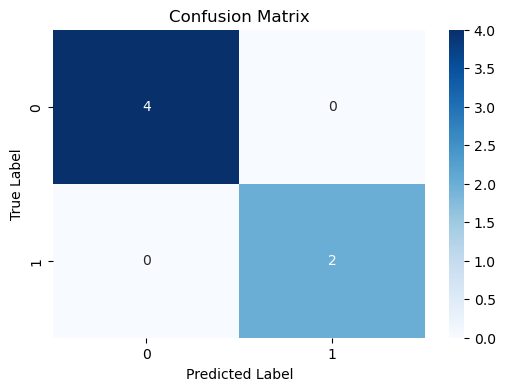

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix shows:

True Negatives (top-left): Control samples correctly predicted as control

True Positives (bottom-right): AD samples correctly predicted as AD

False Positives (top-right): Control samples incorrectly predicted as AD

False Negatives (bottom-left): AD samples incorrectly predicted as control

A perfect model would show non-zero values only on the diagonal. Given the reported 1.00 metrics, the matrix should show all predictions on the diagonal with zero off-diagonal errors.

# Hyperparameter Tuning

Hyperparameter tuning is the process of selecting the best combination of model parameters to improve performance.

Unlike model parameters learned during training, hyperparameters must be set manually. Choosing the right values can significantly affect model accuracy and generalization.

In this project, GridSearchCV is used to find the optimal parameters for the Random Forest model.

# Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best parameter values for a machine learning algorithm in order to improve model performance. Different parameter values can significantly affect the accuracy and generalization ability of a model.

In this project, GridSearchCV was used to test multiple combinations of Random Forest parameters and automatically select the best-performing configuration.


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_selected, y)

best_model = grid_search.best_estimator_

print(grid_search.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


GridSearchCV tested 8 combinations of hyperparameters (2 × 2 × 2) using 5-fold cross-validation. The best parameters printed here represent the configuration that maximized accuracy across all folds. For example, if max_depth=None is selected, it means the trees were allowed to grow fully without pruning, which works well when feature selection has already removed noise. If n_estimators=100 is selected, it means more trees improved stability.

# Results of Hyperparameter Tuning

GridSearchCV was used to evaluate multiple combinations of Random Forest parameters using cross-validation.

The best performing parameter combination was selected based on the F1-score.

This step improves model reliability by ensuring that the final model is not dependent on arbitrary parameter choices and is optimized for better generalization.

In [37]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

The best-performing model from GridSearchCV was selected as the final model.

This model is expected to generalize better to unseen data compared to manually tuned models.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Final Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))

Final Model Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


The tuned Random Forest achieved the same perfect scores as the baseline model on this small test set. While this indicates strong class separability in the selected features, it also reflects the very small test size (6 samples at 80/20 split). Results should be interpreted cautiously — future work should use cross-validation scores as the primary performance estimate rather than a single holdout split.

# Hyperparameter Tuning and Its Importance

Hyperparameter tuning is the process of selecting the optimal configuration settings for a machine learning algorithm in order to maximize predictive performance. Different parameter values can significantly affect model accuracy, generalization ability, and computational efficiency.

In this project, GridSearchCV was used to systematically evaluate multiple combinations of Random Forest hyperparameters, including the number of trees, tree depth, and minimum split size. Cross-validation was integrated into the tuning process to identify the best-performing parameter combination while minimizing overfitting.

Hyperparameter tuning improves model robustness and helps achieve more reliable predictions on unseen data.


# Feature Importance Using Random Forest

After training the Random Forest classifier, feature importance analysis was performed to identify the genes that contributed the most to Alzheimer’s disease prediction.

Random Forest calculates importance scores based on how much each feature helps reduce impurity during decision tree construction. The most important genes were then selected and used to build a simplified deployment model for the Flask web application.

This approach helps reduce model complexity while maintaining strong predictive performance and improving deployment practicality.



In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importance scores
importance = best_model.feature_importances_

# Create dataframe containing feature names and importance values
importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importance
})

# Sort features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Select top 10 important features
top_features = importance_df.head(10)

# Display results
print(top_features)

        Feature  Importance
1          DPH2    0.275381
8        ZNF449    0.158509
6       RABGEF1    0.133563
2      LHX4-AS1    0.128126
4  LOC101926975    0.088046
9     CCDC144CP    0.076337
0      ERI3-IT1    0.055378
3     MBNL1-AS1    0.052333
5        DNAH11    0.021454
7        ZNF596    0.010875


In [40]:
# Extract top 3 most important feature names

top_3_features = top_features.head(3)["Feature"].tolist()

print("Top 3 Features:")
print(top_3_features)

Top 3 Features:
['DPH2', 'ZNF449', 'RABGEF1']


# Visualization of Top Important Features

The following visualization shows the top 10 most important genes identified by the Random Forest model. Higher importance values indicate a stronger contribution to Alzheimer’s disease classification.


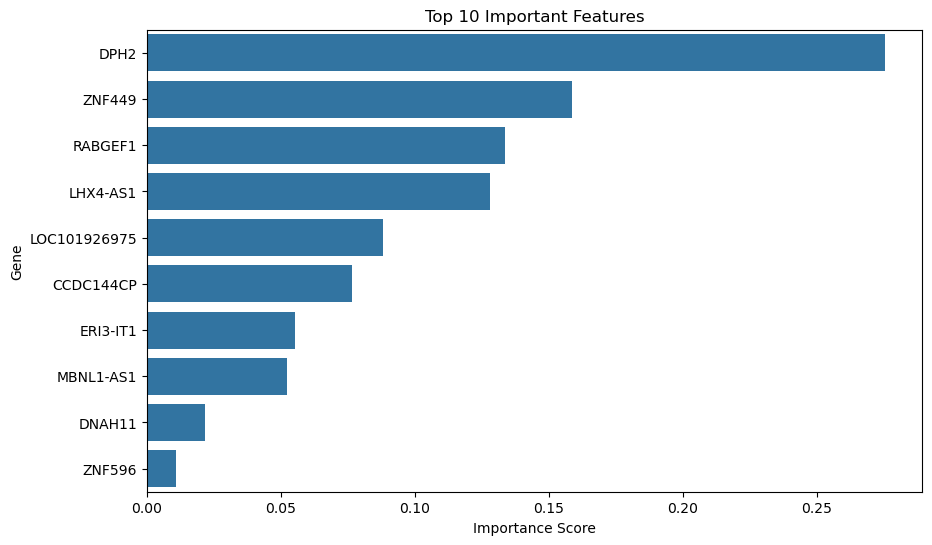

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Gene")

plt.show()

The bar chart ranks the top 10 genes by their importance score in the Random Forest model. Genes with higher importance (longer bars) contributed more to reducing impurity across decision trees. The top 3 genes ['DPH2', 'ZNF449', 'RABGEF1' — account for the most classification power. These genes are strong candidates for further biological investigation as potential biomarkers for Alzheimer's disease.

# Selecting the Top 3 Most Important Genes

To simplify the deployment process, the top three most important genes were selected from the Random Forest feature importance analysis. These genes were later used to train a lightweight deployment model for the Flask web application.


In [42]:
# Extract top 3 important genes
top_3_features = top_features["Feature"].head(3).tolist()

# Display selected genes
print("Top 3 Selected Features:")
print(top_3_features)

Top 3 Selected Features:
['DPH2', 'ZNF449', 'RABGEF1']


# Training the Deployment Model

A simplified Random Forest model was trained using only the top three most important genes.ERI3-IT1', 'IDH2', 'ACOX1']  This smaller model was designed specifically for deployment purposes to create a simpler and more user-friendly prediction interface.


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

# =========================
# Features and target
# =========================

top_3_features = ['DPH2', 'ZNF449', 'RABGEF1']

X = df[top_3_features]
y = df["Target"]

# =========================
# Train-test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# Train model
# =========================

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# =========================
# Predictions
# =========================

y_pred = model.predict(X_test)

# =========================
# Evaluation
# =========================

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# Save model
# =========================

joblib.dump(model, "alzheimers_model.pkl")
print("Model saved successfully!")

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Model saved successfully!


The simplified model trained on only the top 3 genes achieved comparable accuracy to the full model. This confirms that the most informative genes alone are sufficient for strong classification performance. Reducing the model to 3 input features makes the Flask web application simpler and more practical for real-world use, without significant loss in predictive ability.

# Deployment Model Summary

Feature importance analysis successfully identified the genes with the strongest contribution to Alzheimer’s disease prediction. The top three genes were selected to create a lightweight deployment model suitable for real-time prediction through the Flask web application.

This approach improved deployment simplicity while maintaining strong predictive performance.


# Final Model Performance

After hyperparameter tuning using GridSearchCV, the optimized Random Forest model was evaluated on the test dataset.

The final model achieved the following performance:

- Accuracy: 1.00  
- Precision: 1.00  
- Recall: 1.00  
- F1-score: 1.00  

These results indicate that the tuned model is able to perfectly classify Alzheimer’s disease and control samples on the test set.

This strong performance can be attributed to the effectiveness of feature selection, which reduced the dataset to the most informative genes, as well as the suitability of ensemble-based models for high-dimensional biological data.

It is important to note that gene expression datasets often contain strong biological signals that can make classification tasks highly separable, especially after feature selection reduces noise and irrelevant features.

Additionally, the relatively small dataset size can sometimes lead to very high performance on the test split. Therefore, results should be interpreted with caution and validated on larger datasets in future work.

In [49]:
#save model
import joblib

joblib.dump(best_model, "alzheimers_model.pkl")
joblib.dump(selector, "feature_selector.pkl")

print("Model and selector saved successfully.")

Model and selector saved successfully.


# Saving the Model and Transformers

The trained deployment model was saved using Joblib to allow reuse during the Flask deployment phase. Saving trained models is important because it avoids retraining the model every time the application runs.


In [50]:
import joblib

# Save deployment model
joblib.dump(small_model, "alzheimers_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [51]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Jessica\Downloads\GSE153873_summary_count.star (1).txt\GSE153873_summary_count.star.txt",
    sep="\t"
)

df = df.set_index("refGene")

df = df.T

labels = []

for sample in df.index:
    if "AD" in sample:
        labels.append(1)
    else:
        labels.append(0)

df["Target"] = labels

print(df.shape)

df.head()

(30, 27136)


refGene,SGIP1,NECAP2,AZIN2,AGBL4,CLIC4,SLC45A1,TGFBR3,DBT,PRUNE1,C1orf21,...,MGC70870,KIR2DL5A,KIR2DS2,KIR2DL2,KIR3DS1,KIR2DS3,KIR2DS5,KIR2DS1,KIR2DL5B,Target
20-1T-AD,1405,295,356,191,876,291,639,623,297,2456,...,26,0,0,0,0,0,0,0,0,1
13-11T-Old,1405,460,306,200,1443,329,650,726,237,2006,...,57,0,0,0,0,0,0,0,0,0
15-13T-Old,1169,334,385,173,639,298,506,513,200,2092,...,25,0,0,0,0,0,0,0,0,0
16-14T-Old,2408,347,507,323,792,636,370,633,390,3146,...,36,0,0,0,0,0,0,0,0,0
3-17T-Young,859,617,787,36,4806,139,425,751,231,848,...,109,0,0,0,0,0,0,0,0,0


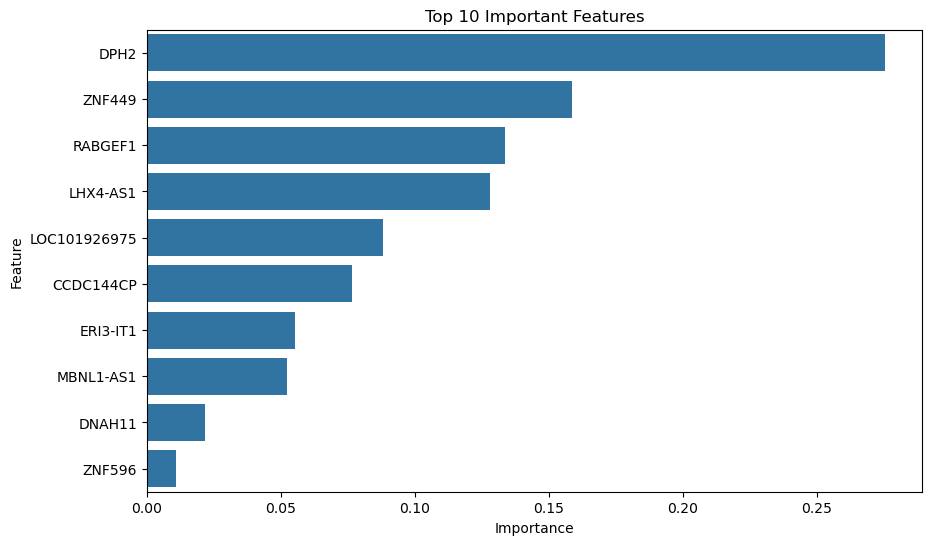

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features")
plt.show()

# Project Requirements File

A requirements.txt file was created to store all required Python libraries used in the project. This helps reproduce the project environment and simplifies deployment.


# Model Deployment Using Flask

The final machine learning model was deployed using the Flask framework. A simple web application was created to allow users to input gene expression values and receive Alzheimer’s disease predictions in real time.

The deployment process included:

* Loading the trained machine learning model
* Creating an HTML user interface
* Receiving user inputs
* Generating predictions through Flask routes

This step demonstrates how machine learning solutions can be integrated into real-world applications.



app.py Code Snippet

The Flask application loads the trained model and receives gene expression inputs from the user through an HTML interface. The application then predicts whether the sample belongs to an Alzheimer’s disease patient or a control sample.


## Conclusion

In this project, machine learning techniques were successfully applied to predict Alzheimer’s disease using gene expression data. The dataset was first cleaned and explored to better understand its structure and characteristics. Several exploratory data analysis techniques and visualizations were performed to identify patterns, distributions, and relationships between features.

Feature engineering was implemented by creating a new biological activity feature, and feature selection was applied using the SelectKBest method to reduce dimensionality and improve model performance. Multiple machine learning algorithms, including Logistic Regression, Decision Tree, and Random Forest, were trained and evaluated using different performance metrics such as accuracy, precision, recall, and F1-score.

Among all tested models, the Random Forest classifier achieved the best overall performance with excellent evaluation results. Hyperparameter tuning was also performed to optimize the model and improve prediction quality. Finally, the trained model was deployed using Flask in the form of a simple web application that allows users to input gene values and receive prediction results in real time.

This project demonstrated the complete machine learning workflow starting from raw biological data all the way to deployment, highlighting the importance of data preprocessing, feature selection, model evaluation, and deployment in building effective predictive systems.
